Random Forest

Dataset Description:

Use the Glass dataset and apply the Random forest model.

1. Exploratory Data Analysis (EDA):

Perform exploratory data analysis to understand the structure of the dataset.
Check for missing values, outliers, inconsistencies in the data.

2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features.
Analyze any patterns or correlations observed in the data.

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

4: Random Forest Model Implementation
1. Divide the data into train and test split.
2. Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
3. Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.


Additional Notes:
1. Explain Bagging and Boosting methods. How is it different from each other.
2. Explain how to handle imbalance in the data.

In [68]:
## import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,GridSearchCV
from sklearn.metrics import accuracy_score,classification_report
from sklearn.preprocessing import StandardScaler,LabelEncoder
import warnings
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier,AdaBoostClassifier
warnings.filterwarnings('ignore')

In [4]:
### read the excel file
file='glass.xlsx'
df=pd.read_excel(file, sheet_name='glass')

In [5]:
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [6]:
df.shape

(214, 10)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 214 entries, 0 to 213
Data columns (total 10 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   RI      214 non-null    float64
 1   Na      214 non-null    float64
 2   Mg      214 non-null    float64
 3   Al      214 non-null    float64
 4   Si      214 non-null    float64
 5   K       214 non-null    float64
 6   Ca      214 non-null    float64
 7   Ba      214 non-null    float64
 8   Fe      214 non-null    float64
 9   Type    214 non-null    int64  
dtypes: float64(9), int64(1)
memory usage: 16.8 KB


In [11]:
### Check Missing Values
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

In [9]:
### check duplicates value
df.duplicated().sum()

np.int64(1)

In [13]:
### Remove duplicates
df.drop_duplicates(inplace=True,ignore_index=True)

In [14]:
df.duplicated().sum()

np.int64(0)

In [15]:
### Statistical View
df.describe()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
count,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000,213.000000
mean,1.518348,13.404085,2.679202,1.449484,72.655070,0.498873,8.954085,0.175869,0.057277,2.788732
std,0.003033,0.816662,1.443691,0.495925,0.773998,0.653185,1.425882,0.498245,0.097589,2.105130
min,1.511150,10.730000,0.000000,0.290000,69.810000,0.000000,5.430000,0.000000,0.000000,1.000000
25%,1.516520,12.900000,2.090000,1.190000,72.280000,0.130000,8.240000,0.000000,0.000000,1.000000
50%,1.517680,13.300000,3.480000,1.360000,72.790000,0.560000,8.600000,0.000000,0.000000,2.000000
75%,1.519150,13.810000,3.600000,1.630000,73.090000,0.610000,9.150000,0.000000,0.100000,3.000000
max,1.533930,17.380000,4.490000,3.500000,75.410000,6.210000,16.190000,3.150000,0.510000,7.000000


2: Data Visualization:

Create visualizations such as histograms, box plots, or pair plots to visualize the distributions and relationships between features. Analyze any patterns or correlations observed in the data.

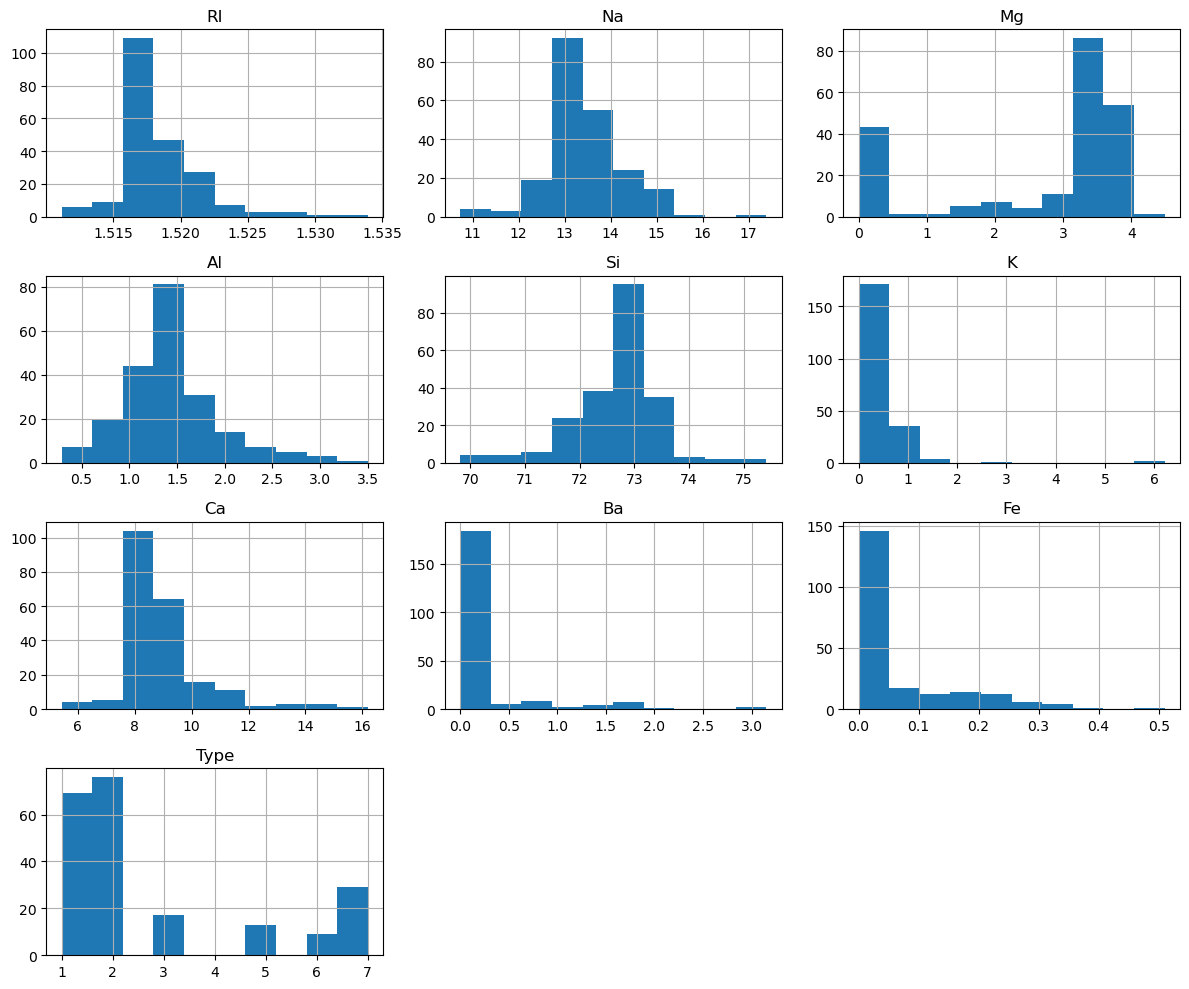

In [16]:
### Histograms
df.hist(figsize=(12,10))
plt.tight_layout()
plt.show()

Observation:
Features are not normally distributed

Tree models do not require normality

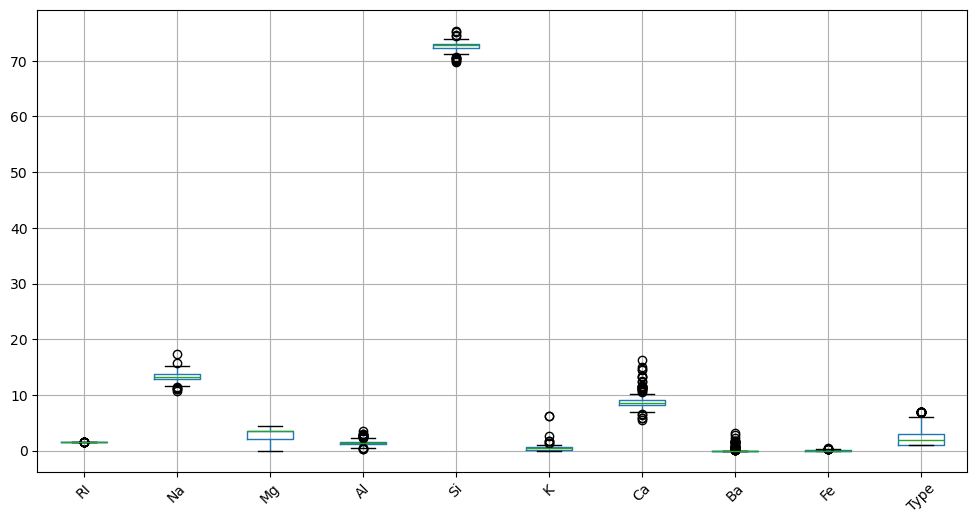

In [17]:
## boxplot
plt.figure(figsize=(12,6))
df.boxplot()
plt.xticks(rotation=45)
plt.show()

In [22]:
### outlier capping
def outlier_capping(df,column):
    Q1= df[column].quantile(0.25)
    Q3= df[column].quantile(0.75)
    IQR= Q3-Q1
    lower_extreme= Q1-1.5*IQR
    upper_extreme= Q3+1.5*IQR
    df[column]= df[column].apply(lambda x: lower_extreme if x<lower_extreme else upper_extreme if x>upper_extreme else x)
for col in df.select_dtypes(['int','float']).columns:
    outlier_capping(df,col)

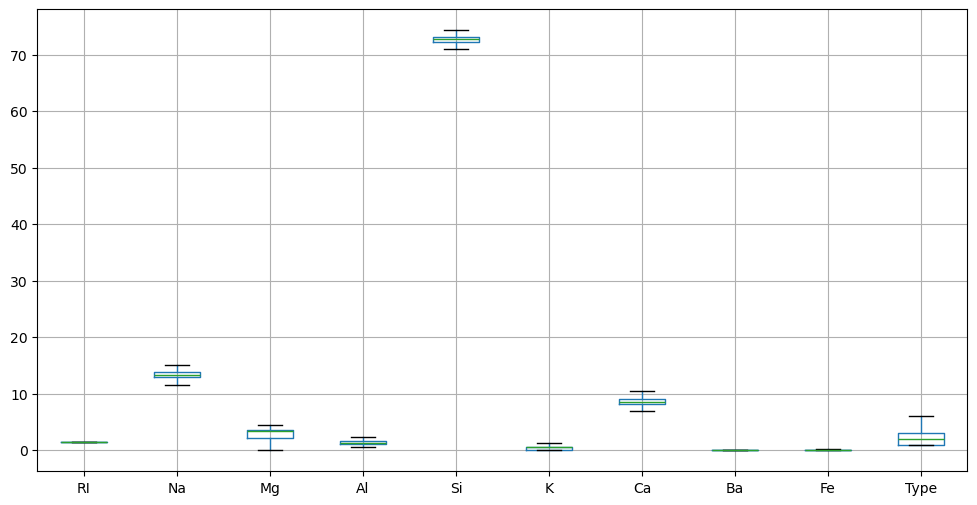

In [23]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.show()

Observation: Outliers present

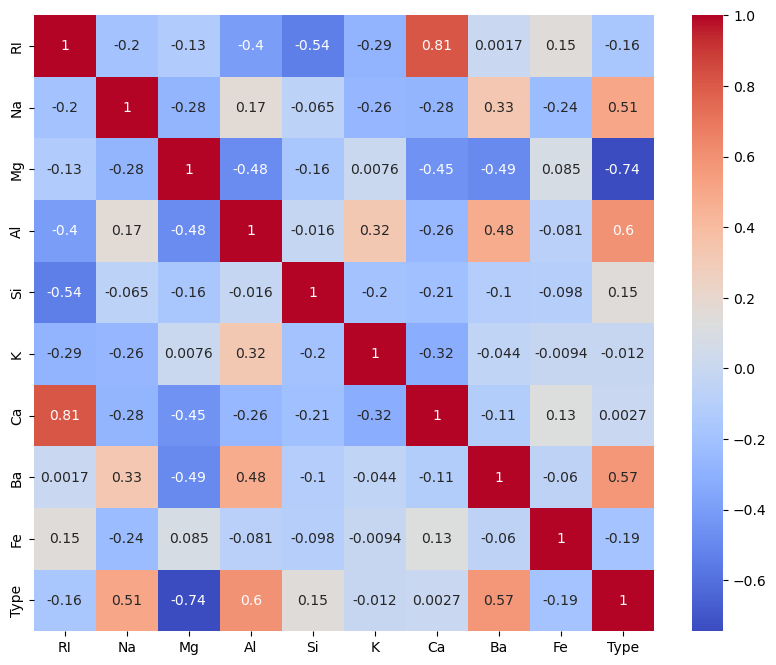

In [18]:
### Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

Observation:

Some moderate correlations

No severe multicollinearity issues

3: Data Preprocessing

1. Check for missing values in the dataset and decide on a strategy for handling them.Implement the chosen strategy (e.g., imputation or removal) and explain your reasoning.
2. If there are categorical variables, apply encoding techniques like one-hot encoding to convert them into numerical format.
3. Apply feature scaling techniques such as standardization or normalization to ensure that all features are on a similar scale. Handling the imbalance data.

In [19]:
df.isnull().sum()

RI      0
Na      0
Mg      0
Al      0
Si      0
K       0
Ca      0
Ba      0
Fe      0
Type    0
dtype: int64

No missing values = No imputation needed

Reason:
Removing or imputing non-existent missing values is unnecessary

Categorical Encoding

No categorical variables

All features are numerical = Encoding not required

In [28]:
target=df[['Type']]
features= df.drop(columns=['Type'])

In [30]:
### fearures scaling
std_sca=StandardScaler()
features=std_sca.fit_transform(features)

In [34]:
target.value_counts()

Type
2.0     76
1.0     69
6.0     38
3.0     17
5.0     13
Name: count, dtype: int64

Observation:

Glass dataset is imbalanced

Some glass types have fewer samples

Technique Used: class_weight="balanced"

In [37]:
### Train-Test Split
x_train,x_test,y_train,y_test= train_test_split(features,target,train_size=0.8,random_state=42)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(170, 9)
(43, 9)
(170, 1)
(43, 1)


 4: Random Forest Model Implementation

Divide the data into train and test split.
Implement a Random Forest classifier using Python and a machine learning library like scikit-learn.
Train the model on the train dataset. Evaluate the performance on test data using metrics like accuracy, precision, recall, and F1-score.

In [82]:
rand_for= RandomForestClassifier(n_estimators=200,bootstrap=True,random_state=50,max_samples=0.7,max_features='sqrt',class_weight='balanced')
rand_for.fit(x_train,y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [67]:
### Model Evaluation
y_pred= rand_for.predict(x_test)
accuracy_score(y_test,y_pred)


0.7674418604651163

In [51]:
### Classification Report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         1.0       0.77      1.00      0.87        10
         2.0       0.75      0.80      0.77        15
         3.0       1.00      0.33      0.50         3
         5.0       0.75      1.00      0.86         3
         6.0       1.00      0.75      0.86        12

    accuracy                           0.81        43
   macro avg       0.85      0.78      0.77        43
weighted avg       0.84      0.81      0.81        43



In [48]:
#### Using GridSearch
params={'n_estimators':[50,100,150,200],'max_samples':[0.7,0.8,0.9,1]}
grid_search= GridSearchCV(rand_for,params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'max_samples': 0.7, 'n_estimators': 200}

5: Bagging and Boosting Methods
Apply the Bagging and Boosting methods and compare the results.

#### Bagging

In [53]:
from sklearn.tree import DecisionTreeClassifier

In [64]:
bag_class= BaggingClassifier(estimator=DecisionTreeClassifier(),n_estimators=150,bootstrap=True,random_state=50,
                            max_features=0.5,bootstrap_features=True,max_samples=0.9)

In [65]:
bag_class.fit(x_train,y_train)
y_pred= bag_class.predict(x_test)
accuracy_score(y_test,y_pred)

0.7906976744186046

In [57]:
#### Using GridSearch
params={'n_estimators':[50,100,150,200],'max_samples':[0.7,0.8,0.9,1],}
grid_search= GridSearchCV(bag_class,params,cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'max_samples': 0.9, 'n_estimators': 150}

#### AdaBoosting

In [77]:
ada_boost= AdaBoostClassifier(estimator=DecisionTreeClassifier(),n_estimators=50,learning_rate=0.5,random_state=50)
ada_boost.fit(x_train,y_train)
y_pred= ada_boost.predict(x_test)
accuracy_score(y_test,y_pred)

0.7674418604651163

In [74]:
#### Using Gridsearch
params= {'n_estimators':[50,100,150,200],'learning_rate':[0,0.5,1]}
grid_search= GridSearchCV(ada_boost,params, cv=5)
grid_search.fit(x_train,y_train)
grid_search.best_params_

{'learning_rate': 0.5, 'n_estimators': 50}

Random Forest handles imbalanced data effectively and is highly robust to noise and outliers; therefore, it achieves high accuracy.

Bagging reduces model variance by averaging multiple independent models, resulting in moderate accuracy.

Boosting reduces bias by focusing on misclassified samples in successive models, often achieving high accuracy, but it may overfit if not properly controlled.

### What is Bagging?

Trains multiple models on random bootstrap samples

Final prediction via majority voting

Reduces variance

###  What is Boosting?

Trains models sequentially

Focuses more on misclassified samples

Reduces bias

### Difference

Bagging trains multiple models in parallel, whereas Boosting trains models sequentially.

Bagging primarily focuses on reducing variance, while Boosting aims to reduce bias.

In Bagging, all models are given equal weight, whereas in Boosting, models are assigned adaptive weights based on their performance.

Bagging is less prone to overfitting, while Boosting can overfit if the model becomes too complex.

#### Handling Imbalanced Data

Imbalanced data can be handled by using resampling techniques such as oversampling (e.g., SMOTE) or undersampling, applying class weights to give more importance to minority classes, and using ensemble methods like Random Forest or Boosting. Instead of relying only on accuracy, evaluation metrics such as precision, recall, and F1-score should be used to properly assess model performance.